--- 🚲 CARGANDO DATOS ---
Train: 2131 | Test: 110
Entrenando SOLO LASSO...
✅ Gráficas SOLO LASSO generadas.


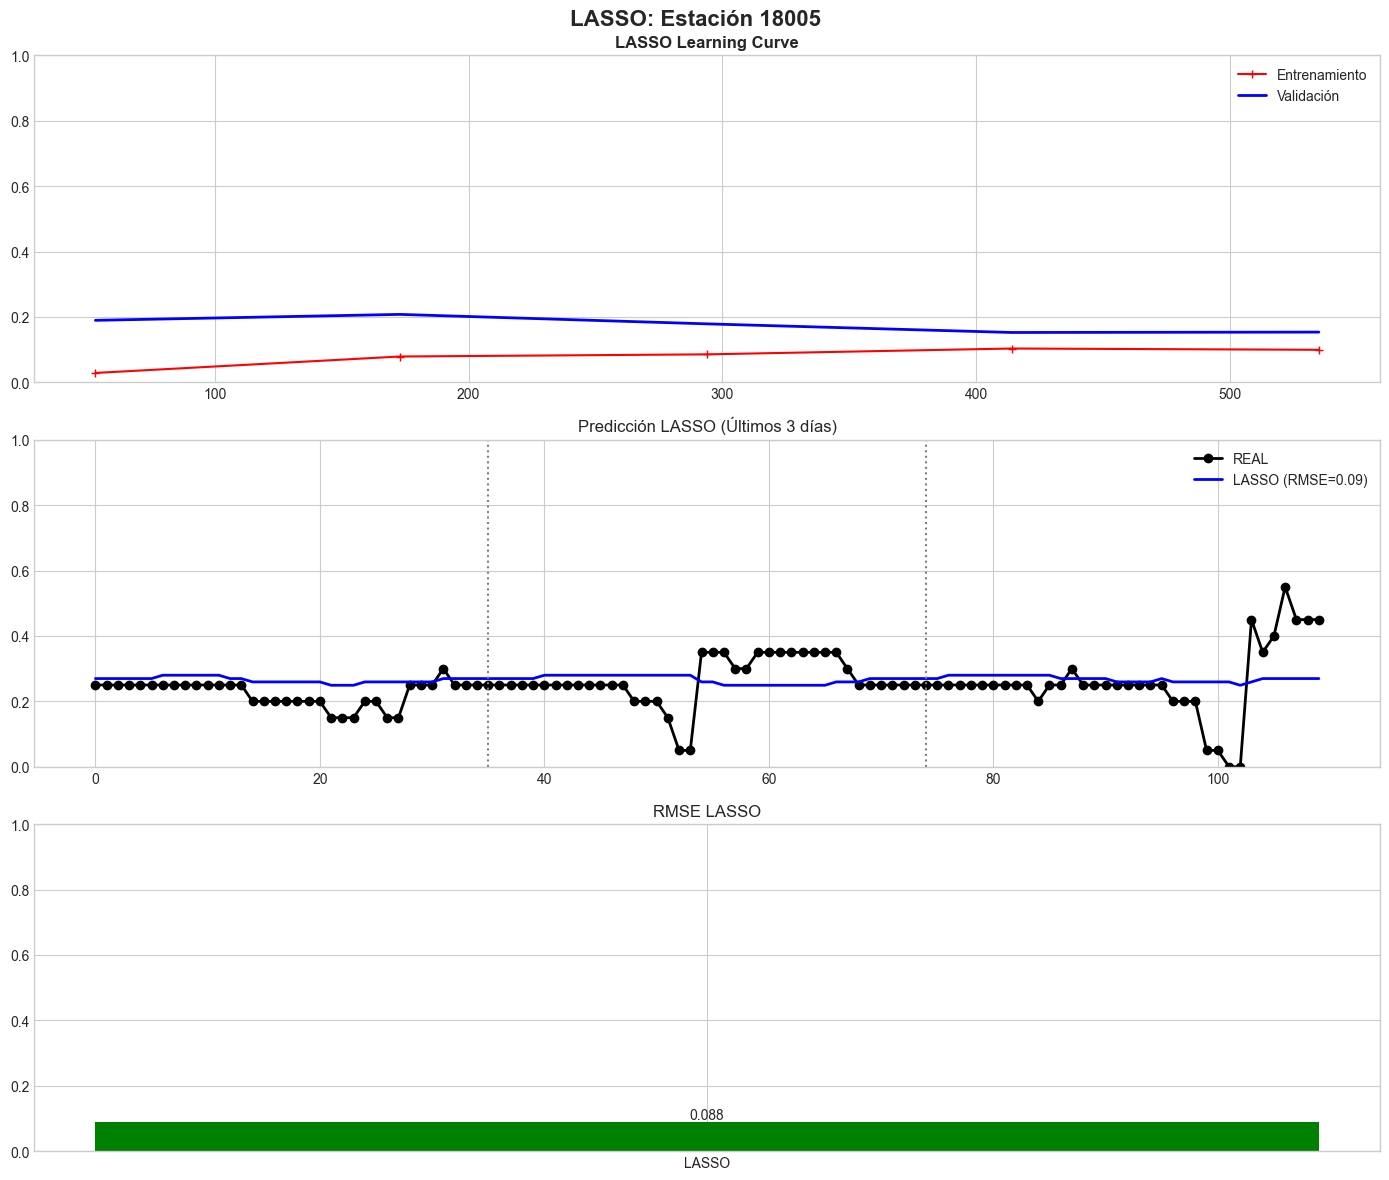

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import learning_curve, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("--- 🚲 CARGANDO DATOS ---")
df = pd.read_csv('citybike_procesado.csv')
df['fecha_dt'] = pd.to_datetime(df['fecha'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Estación
STATION_ID = 18005
df_est = df[df['codigo_estacion'] == STATION_ID].sort_values('timestamp')
df_est = df_est.dropna(subset=['hora', 'temp_c', 'ocupacion'])


# Variables
X = df_est[['hora', 'temp_c']].values
y = df_est['ocupacion'].values

# Split (últimos 3 días)
dias_unicos = df_est['fecha_dt'].dt.date.unique()
dias_test = dias_unicos[-3:]
idx_test = df_est['fecha_dt'].dt.date.isin(dias_test)

X_train = X[~idx_test]
y_train = y[~idx_test]
X_test = X[idx_test]
y_test = y[idx_test]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ==========================================
# 2. SOLO MODELO LASSO
# ==========================================
GRADO = 8

def crear_pipeline(modelo, params):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])
    return GridSearchCV(pipe, params, cv=TimeSeriesSplit(n_splits=3),
                        scoring='neg_root_mean_squared_error')

print("Entrenando SOLO LASSO...")

model_lasso = crear_pipeline(
    Lasso(max_iter=10000, tol=1e-3),
    {'model__alpha': [0.001, 0.01, 0.1]}
)

model_lasso.fit(X_train, y_train)
lasso_best = model_lasso.best_estimator_

# ==========================================
# 3. FUNCIÓN CURVA
# ==========================================
def graficar_curva(model, X, y, ax, titulo):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=TimeSeriesSplit(n_splits=3),
        scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.sqrt(-np.mean(train_scores, axis=1))
    val_mean = np.sqrt(-np.mean(val_scores, axis=1))

    ax.plot(train_sizes, train_mean, 'r-+', linewidth=1.5, label='Entrenamiento')
    ax.plot(train_sizes, val_mean, 'b-', linewidth=2, label='Validación')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend()

# ==========================================
# 4. GRÁFICAS
# ==========================================
fig = plt.figure(figsize=(14, 12))
plt.suptitle(f"LASSO: Estación {STATION_ID}", fontsize=16, fontweight='bold')

# Curva aprendizaje
ax1 = fig.add_subplot(3, 1, 1)
graficar_curva(lasso_best, X_train, y_train, ax1, "LASSO Learning Curve")

# Predicciones
ax2 = fig.add_subplot(3, 1, 2)
x_vals = np.arange(len(y_test))

ax2.plot(x_vals, y_test, 'k-o', label='REAL', linewidth=2)
preds = lasso_best.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

ax2.plot(x_vals, preds, color='blue', linewidth=2, label=f'LASSO (RMSE={rmse:.2f})')

# Líneas de separación diaria
fechas_test = df_est[idx_test]['fecha_dt'].dt.date.values
cambios = np.where(fechas_test[:-1] != fechas_test[1:])[0] + 1
for c in cambios:
    ax2.axvline(x=c, color='gray', linestyle=':')

ax2.set_title("Predicción LASSO (Últimos 3 días)")
ax2.set_ylim(0, 1)
ax2.legend()

# Ranking (solo 1 modelo)
ax3 = fig.add_subplot(3, 1, 3)
ax3.bar(["LASSO"], [rmse], color="green", width=0.5)
ax3.set_title("RMSE LASSO")
ax3.set_ylim(0, 1)
ax3.bar_label(ax3.containers[0], fmt="%.3f")

plt.tight_layout()
plt.savefig('analisis_lasso.png')
print("✅ Gráficas SOLO LASSO generadas.")
plt.show()


In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# 1. CARGA DE DATOS
print("--- 🚲 CARGANDO Y PROCESANDO DATOS ---")
df = pd.read_csv('citybike_procesado.csv')
df['fecha_dt'] = pd.to_datetime(df['fecha'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. SELECCIONAR TOP 50 ESTACIONES
top_50_stations = df['codigo_estacion'].value_counts().head(50).index.tolist()
print(f"Analizando las {len(top_50_stations)} estaciones con más datos...")

# 3. DEFINICIÓN DE PIPELINES (GRADO 5)
GRADO = 5

def get_best_model_for_station(station_id):
    # Filtrar datos de la estación
    df_est = df[df['codigo_estacion'] == station_id].sort_values('timestamp')
    
    # Variables
    X = df_est[['hora', 'temp_c']].values
    y = df_est['ocupacion'].values
    
    # Split Train/Test (Últimos 3 días)
    dias_unicos = df_est['fecha_dt'].dt.date.unique()
    if len(dias_unicos) < 5: # Skip stations with too few days
        return None
        
    dias_test = dias_unicos[-3:]
    idx_test = df_est['fecha_dt'].dt.date.isin(dias_test)
    
    X_train = X[~idx_test]
    y_train = y[~idx_test]
    X_test = X[idx_test]
    y_test = y[idx_test]
    
    if len(X_train) == 0 or len(X_test) == 0:
        return None

    # Definir Modelos
    # Usamos parámetros fijos 'buenos' para velocidad, o GridSearch rápido
    # Para 50 estaciones, GridSearch completo puede ser lento. Usaremos GridSearch ligero.
    
    cv = TimeSeriesSplit(n_splits=2) # 2 splits para velocidad
    
    # A. RIDGE
    pipe_ridge = Pipeline([
        ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ])
    gs_ridge = GridSearchCV(pipe_ridge, {'model__alpha': [0.1, 1, 10]}, 
                            cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    gs_ridge.fit(X_train, y_train)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, gs_ridge.predict(X_test)))

    # B. LASSO
    pipe_lasso = Pipeline([
        ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Lasso(max_iter=5000, tol=1e-2)) # tol relajada para velocidad
    ])
    gs_lasso = GridSearchCV(pipe_lasso, {'model__alpha': [0.001, 0.01, 0.1]}, 
                            cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    gs_lasso.fit(X_train, y_train)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, gs_lasso.predict(X_test)))

    # C. ELASTICNET
    pipe_en = Pipeline([
        ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', ElasticNet(max_iter=5000, tol=1e-2))
    ])
    gs_en = GridSearchCV(pipe_en, {'model__alpha': [0.001, 0.01], 'model__l1_ratio': [0.5]}, 
                         cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    gs_en.fit(X_train, y_train)
    rmse_en = np.sqrt(mean_squared_error(y_test, gs_en.predict(X_test)))

    # D. MINI-BATCH SGD
    # SGD es sensible, usamos un config robusto fijo
    pipe_sgd = Pipeline([
        ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', SGDRegressor(learning_rate='adaptive', eta0=0.01, max_iter=2000, random_state=42))
    ])
    pipe_sgd.fit(X_train, y_train)
    rmse_sgd = np.sqrt(mean_squared_error(y_test, pipe_sgd.predict(X_test)))
    
    # Comparar
    results = {
        'Ridge': rmse_ridge,
        'Lasso': rmse_lasso,
        'ElasticNet': rmse_en,
        'Mini-Batch SGD': rmse_sgd
    }
    
    best_model_name = min(results, key=results.get)
    best_rmse = results[best_model_name]
    
    return {
        'station_id': station_id,
        'winner': best_model_name,
        'best_rmse': best_rmse,
        'all_results': results
    }

# Ejecutar análisis
results_list = []
print("Procesando estaciones (esto puede tomar unos minutos)...")
for i, station in enumerate(top_50_stations):
    res = get_best_model_for_station(station)
    if res:
        results_list.append(res)
    if (i+1) % 10 == 0:
        print(f"Procesadas {i+1} estaciones...")

# Convertir a DataFrame
df_results = pd.DataFrame(results_list)

# Análisis Final
print("\n--- RESUMEN FINAL ---")
print(f"Total estaciones analizadas con éxito: {len(df_results)}")

winner_counts = df_results['winner'].value_counts()
print("\nConteo de Ganadores (Frecuencia):")
print(winner_counts)

# Promedio de RMSE por tipo de modelo
avg_errors = {
    'Ridge': np.mean([r['all_results']['Ridge'] for r in results_list]),
    'Lasso': np.mean([r['all_results']['Lasso'] for r in results_list]),
    'ElasticNet': np.mean([r['all_results']['ElasticNet'] for r in results_list]),
    'Mini-Batch SGD': np.mean([r['all_results']['Mini-Batch SGD'] for r in results_list])
}

print("\nError Promedio (RMSE) por Modelo a través de todas las estaciones:")
for m, e in avg_errors.items():
    print(f"{m}: {e:.5f}")

overall_best_station = df_results.loc[df_results['best_rmse'].idxmin()]
print(f"\nLa estación con el menor error absoluto fue {overall_best_station['station_id']} usando {overall_best_station['winner']} (RMSE: {overall_best_station['best_rmse']:.5f})")

import matplotlib.pyplot as plt

# ============================
#  GRAFICO DE BARRAS DE GANADORES
# ============================

modelo_ganadores = df_results['winner'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(modelo_ganadores.index, modelo_ganadores.values)

plt.title("Cantidad de Estaciones Ganadas por Cada Modelo", fontsize=16, fontweight='bold')
plt.ylabel("Número de Estaciones", fontsize=12)
plt.xlabel("Modelo", fontsize=12)

# Colorear barra del modelo más ganador
max_model = modelo_ganadores.idxmax()
for bar, label in zip(bars, modelo_ganadores.index):
    if label == max_model:
        bar.set_color('green')
    else:
        bar.set_color('gray')

# ============================
#  AGREGAR LISTA DE ESTACIONES POR MODELO
# ============================

def obtener_estaciones(modelo):
    return df_results[df_results['winner'] == modelo]['station_id'].tolist()

for bar, modelo in zip(bars, modelo_ganadores.index):
    estaciones = obtener_estaciones(modelo)
    texto = ", ".join(map(str, estaciones))  # Ej: "18007, 18005, ..."
    # Mostrar ID de estaciones arriba de cada barra
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        texto,
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90,
        wrap=True
    )

plt.tight_layout()
plt.show()

--- 🚲 CARGANDO Y PROCESANDO DATOS ---
Analizando las 50 estaciones con más datos...
Procesando estaciones (esto puede tomar unos minutos)...


ValueError: 
All the 6 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dilan\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dilan\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Dilan\AppData\Roaming\Python\Python314\site-packages\sklearn\pipeline.py", line 655, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "C:\Users\Dilan\AppData\Roaming\Python\Python314\site-packages\sklearn\pipe